# **Install pakages required**

In [1]:
install.packages(c("epiDisplay", "broom.mixed", "WeightIt","gbm", "cobalt","lmtest","sandwich"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘coda’, ‘furrr’, ‘chk’, ‘gridExtra’, ‘zoo’




# **Library packages**

In [2]:
library(epiDisplay)
library(tidyverse)
library(broom.mixed)
library(WeightIt)
library(gbm)
library(cobalt)
library(lmtest)
library(sandwich)
library(scales)

Loading required package: foreign

Loading required package: survival

Loading required package: MASS

Loading required package: nnet

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ ggplot2::alpha() masks epiDisplay::alpha()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ dplyr::select()  masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3

 cobalt (Version 4.6.2, Build Date: 2026-01-29)

Loading required package: zoo


Attaching package: ‘zoo’


The 

# **Import data**

In [3]:
ap<-readRDS("demo_ap.rds")

Explore 'ap'

In [4]:
glimpse(ap)

Rows: 404
Columns: 23
$ id      <chr> "0-1", "0-10", "0-11", "0-12", "0-13", "0-14", "0-15", "0-16",…
$ group   <chr> "tnc", "tnc", "tnc", "tnc", "tnc", "tnc", "tnc", "tnc", "tnc",…
$ east    <lgl> TRUE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, …
$ mage    <fct> >=35, 20-34, 20-34, 20-34, <20, 20-34, 20-34, 20-34, 20-34, 20…
$ gage    <fct> <37, 37-41, 37-41, 37-41, 37-41, 37-41, 37-41, 37-41, 37-41, 3…
$ mode    <chr> "cs", "vg", "vg", "vg", "cs", "cs", "vg", "cs", "cs", "cs", "c…
$ income  <ord> 21-40 percentile, 41-60 percentile, 21-40 percentile, 21-40 pe…
$ smoke   <lgl> TRUE, FALSE, FALSE, FALSE, TRUE, TRUE, TRUE, FALSE, TRUE, FALS…
$ panc    <chr> "public", "public", "public", "public", "public", "private", "…
$ p       <chr> ">=4", "2", "1", "0", "1", "0", "2", "0", "0", "0", "2", "0", …
$ wanc    <ord> Second Trimester, Second Trimester, Second Trimester, First Tr…
$ ap      <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, TRUE, FALSE, FALSE, FALSE, …
$ manuap  <chr> "N

In [5]:
hos<-readRDS("hos.rds")

Explore 'hos'

In [6]:
glimpse(hos)

Rows: 33
Columns: 12
$ id        <chr> "1-0", "2-0", "3-0", "4-0", "5-0", "6-0", "7-0", "8-0", "9-0…
$ cough     <lgl> TRUE, TRUE, TRUE, FALSE, FALSE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ cyanosis  <lgl> FALSE, FALSE, FALSE, TRUE, FALSE, FALSE, TRUE, TRUE, FALSE, …
$ whooping  <lgl> TRUE, FALSE, TRUE, FALSE, TRUE, TRUE, FALSE, FALSE, FALSE, F…
$ apnea     <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, TRUE, FALSE, FALSE, FALSE…
$ seizure   <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, TRUE, FALSE, FALSE, FALSE…
$ admit     <lgl> FALSE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…
$ ett       <lgl> FALSE, FALSE, FALSE, TRUE, TRUE, TRUE, FALSE, FALSE, FALSE, …
$ pnuemo    <lgl> FALSE, FALSE, FALSE, TRUE, TRUE, TRUE, FALSE, TRUE, FALSE, F…
$ dead      <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, TRUE, FALSE, FALSE, FALSE…
$ onset_dur <dbl> 7, 14, 7, 5, 4, 14, 5, 14, 13, 10, 2, 3, 8, 5, 13, 7, 6, 2, …
$ los       <dbl> NA, 1, 4, 22, 18, 2, 1, 1, 6, 4, 8, 23, 2, 6, 1, 1, 1, 13, N…


# **Data dictionary**

**ap data**

| Variable | Type | Description | Levels / Examples |
| :--- | :--- | :--- | :--- |
| **id** | `chr` | Unique participant identifier | "1-0", "1-1" |
| **group** | `chr` | Study group classification | case, com-control,Test-negative control |
| **east** | `lgl` | Living in East zone | TRUE=East, FALSE=West |
| **mage** | `fct` | Maternal age (years) | <20, 20-34, >=35 |
| **gage** | `fct` | Gestational age (weeks) at child birth | <37, 37-41, >41 |
| **mode** | `chr` | Delivery method | cs (C-section), vg (Vaginal) |
| **income** | `ord` | Household income percentile | ≤20, 21-40, 41-60, 61-80, >80 |
| **smoke** | `lgl` | Smoking in household | TRUE, FALSE |
| **panc** | `chr` | Prenatal care clinic type | public, private |
| **p** | `chr` | Parity (Previous live births) | 0, 1, 2, 3, >=4 |
| **wanc** | `ord` | Trimester of first ANC visit | First, Second, Third |
| **ap** | `lgl` | Maternal aP vaccination | TRUE, FALSE |
| **manuap** | `chr` | aP vaccine manufacturer | Pertagen-aP, Boostagen-TdaP |
| **gap** | `chr` | Gestational age at maternal aP vaccination | 24–30, >31, No vaccination |
| **fluvac** | `chr` | Maternal flu vaccination | Yes, No |
| **sex** | `chr` | Child sex | Male, Female |
| **cage** | `fct` | Current infant age (months) | 1, 2, 3 |
| **eperiod** | `chr` | Enrollment period | Q4-2023 to Q3-2024 |
| **bap** | `chr` | Infant pertussis vaccine type | DTwP, DTaP, None |
| **milk** | `chr` | Infant feeding method | breast, formula, mixed |
| **hhchild** | `chr` | Children in household | 1, 2, 3, >=4 |
| **school** | `chr` | School-aged sibling | 0, 1, >=2 |
| **bw** | `dbl` | Birth weight (grams) | Continuous (Mean: ~3000g) |

Zonal explaination

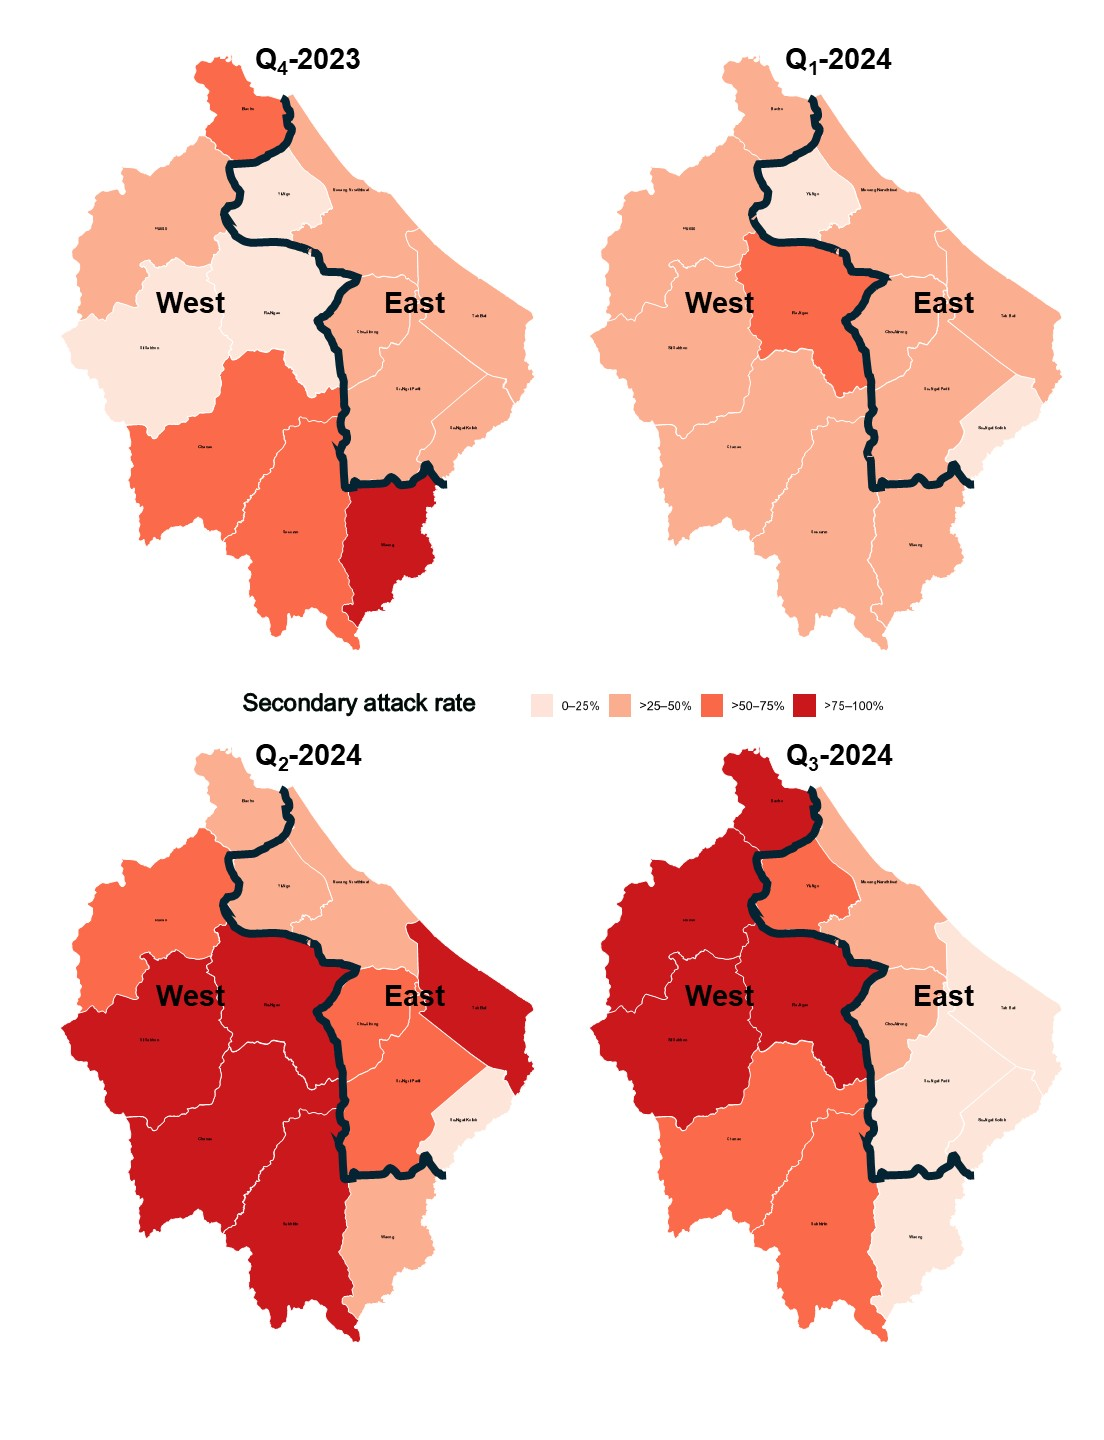

**In-hospital data of the cases**

### Data Dictionary: Clinical Symptoms and Outcomes

| Variable | Type | Description | Values / Units |
| :--- | :--- | :--- | :--- |
| **id** | `chr` | Unique participant identifier | String (e.g., "1-0") |
| **cough** | `lgl` | Presence of coughing > 7 days | TRUE / FALSE |
| **cyanosis** | `lgl` | Bluish skin/lips due to lack of oxygen | TRUE / FALSE |
| **whooping** | `lgl` | High-pitched "whoop" sound on inhalation | TRUE / FALSE |
| **apnea** | `lgl` | Temporary cessation of breathing | TRUE / FALSE |
| **seizure** | `lgl` | Occurrence of convulsions or seizures | TRUE / FALSE |
| **admit** | `lgl` | Require hospitalization | TRUE / FALSE |
| **ett** | `lgl` | Endotracheal Tube (Intubation/Ventilation) | TRUE / FALSE |
| **pnuemo** | `lgl` | Diagnosis of Pneumonia | TRUE / FALSE |
| **dead** | `lgl` | Patient mortality (Death) | TRUE / FALSE |
| **onset_dur** | `dbl` | Duration of symptoms before clinical presentation | Days |
| **los** | `dbl` | Length of Stay in the hospital | Days |

---

# **Demographic table**

In [7]:
tableStack(east:bw,by=group,dat=ap,test = F, total.column = T)

                                case           com-control    tnc           
Total                           33             330            41            
                                                                            
east                                                                        
   FALSE                        16 (48.5)      160 (48.5)     23 (56.1)     
   TRUE                         17 (51.5)      170 (51.5)     18 (43.9)     
                                                                            
mage                                                                        
   <20                          1 (3)          24 (7.3)       2 (4.9)       
   20-34                        24 (72.7)      254 (77)       35 (85.4)     
   >=35                         8 (24.2)       52 (15.8)      4 (9.8)       
                                                                            
gage                                                                        

In [8]:
round(mean(ap$bw),1);round(sd(ap$bw),1)

[1] 3063.9

[1] 414.1

# **Case VS Community Control**

Subgroup data into matched sets

In [9]:
cc<-ap[ap$group!="tnc",]
cc$case<-cc$group=="case"
cc$mat<-str_extract(cc$id, "^\\d+")

IPTW

In [10]:
set.seed(123)
w.out <- weightit(
  formula  = ap ~ east + mage + gage + mode + income + smoke + wanc + panc + fluvac + sex + cage+ eperiod + bap + milk + hhchild + school + bw,
  data     = cc,
  method   = "gbm",
  estimand = "ATE",
  stabilize= TRUE,
  stop.method = "smd.mean")

Assign weight

In [11]:
cc$iptw<-w.out$weights

Review the comparison

In [12]:
bal_stats <- bal.tab(w.out, un = TRUE, stats = "m", abs = TRUE)$Balance %>%
  as.data.frame() %>%
  tibble::rownames_to_column("variable") %>%
  mutate(variable = gsub("_.*", "", variable)) %>%
  group_by(variable) %>%
  slice(1) %>%
  select(variable, SMD_Pre = Diff.Un, SMD_Post = Diff.Adj)
covs <- c("east", "mage", "gage", "mode", "income", "smoke",
                "wanc", "panc", "fluvac", "sex",
                "cage", "eperiod", "bap", "milk", "hhchild", "school")
get_stats <- function(data, weight_col) {
  data %>%
    # Ensure all are characters so pivot_longer works
    mutate(across(all_of(covs), as.character)) %>%
    pivot_longer(cols = all_of(covs), names_to = "variable", values_to = "level") %>%
    group_by(variable, ap, level) %>%
    # Sum the weights (weight=1 for pre, iptw for post)
    summarise(n_weighted = sum(!!sym(weight_col), na.rm = TRUE), .groups = "drop") %>%
    group_by(variable, ap) %>%
    mutate(prop = n_weighted / sum(n_weighted)) %>%
    ungroup() %>%
    mutate(stat = paste0(round(n_weighted, 1), " (", round(prop * 100, 1), "%)")) %>%
    select(variable, level, ap, stat) %>%
    pivot_wider(names_from = ap, values_from = stat)
}
cc$one <- 1
pre_table  <- get_stats(cc, "one") %>% rename(Pre_F = `FALSE`, Pre_T = `TRUE`)
post_table <- get_stats(cc, "iptw") %>% rename(Post_F = `FALSE`, Post_T = `TRUE`)
final_table <- pre_table %>%
  left_join(post_table, by = c("variable", "level")) %>%
  left_join(bal_stats, by = "variable") %>%
  # Add the continuous 'bw' means/SDs as a separate step if desired
  arrange(variable, level)

Show pre-weighting vs post-weighting result (NA=0)

In [13]:
final_table<-final_table %>% select(variable, level,  Pre_T, Pre_F, SMD_Pre, Post_T, Post_F,  SMD_Post)
names(final_table) <- c("variable", "level","Pre_aP", "Pre_No_aP", "SMD_Pre","Post_aP", "Post_No_aP",  "SMD_Post")
final_table

variable,level,Pre_aP,Pre_No_aP,SMD_Pre,Post_aP,Post_No_aP,SMD_Post
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
bap,DTaP,2 (2.3%),15 (5.4%),0.030895811,1.3 (2.6%),13.2 (5.1%),0.0247291861
bap,DTwP,48 (55.8%),142 (51.3%),0.030895811,25.9 (52.4%),137.5 (52.8%),0.0247291861
bap,None,36 (41.9%),120 (43.3%),0.030895811,22.3 (45%),109.5 (42.1%),0.0247291861
cage,1,11 (12.8%),33 (11.9%),0.008773403,5.6 (11.3%),31.3 (12%),0.0069536551
cage,2,6 (7%),71 (25.6%),0.008773403,3.8 (7.7%),59.4 (22.8%),0.0069536551
cage,3,69 (80.2%),173 (62.5%),0.008773403,40.1 (80.9%),169.5 (65.1%),0.0069536551
east,FALSE,26 (30.2%),150 (54.2%),0.239190664,20.2 (40.8%),132.9 (51%),0.1024175631
east,TRUE,60 (69.8%),127 (45.8%),0.239190664,29.3 (59.2%),127.4 (49%),0.1024175631
eperiod,Q1-2024,7 (8.1%),96 (34.7%),0.265175048,6.6 (13.3%),78.4 (30.1%),0.1681015447


Total N for each arm (actual/pseudo-population)

In [14]:
cc %>%
  group_by(ap) %>%
  summarise(
    n_pre = n(),
    n_post = sum(iptw, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  # Reshape to match the final_table structure
  summarise(
    variable = "Total N",
    Pre_aP = as.character(round(n_pre[ap == TRUE], 1)),
    Pre_No_aP = as.character(round(n_pre[ap == FALSE], 1)),
    Post_aP = as.character(round(n_post[ap == TRUE], 1)),
    Post_No_aP = as.character(round(n_post[ap == FALSE], 1)))

variable,Pre_aP,Pre_No_aP,Post_aP,Post_No_aP
<chr>,<chr>,<chr>,<chr>,<chr>
Total N,86,277,49.5,260.3


Check stability of IPTW

In [15]:
options(repr.plot.width = 14, repr.plot.height = 10)

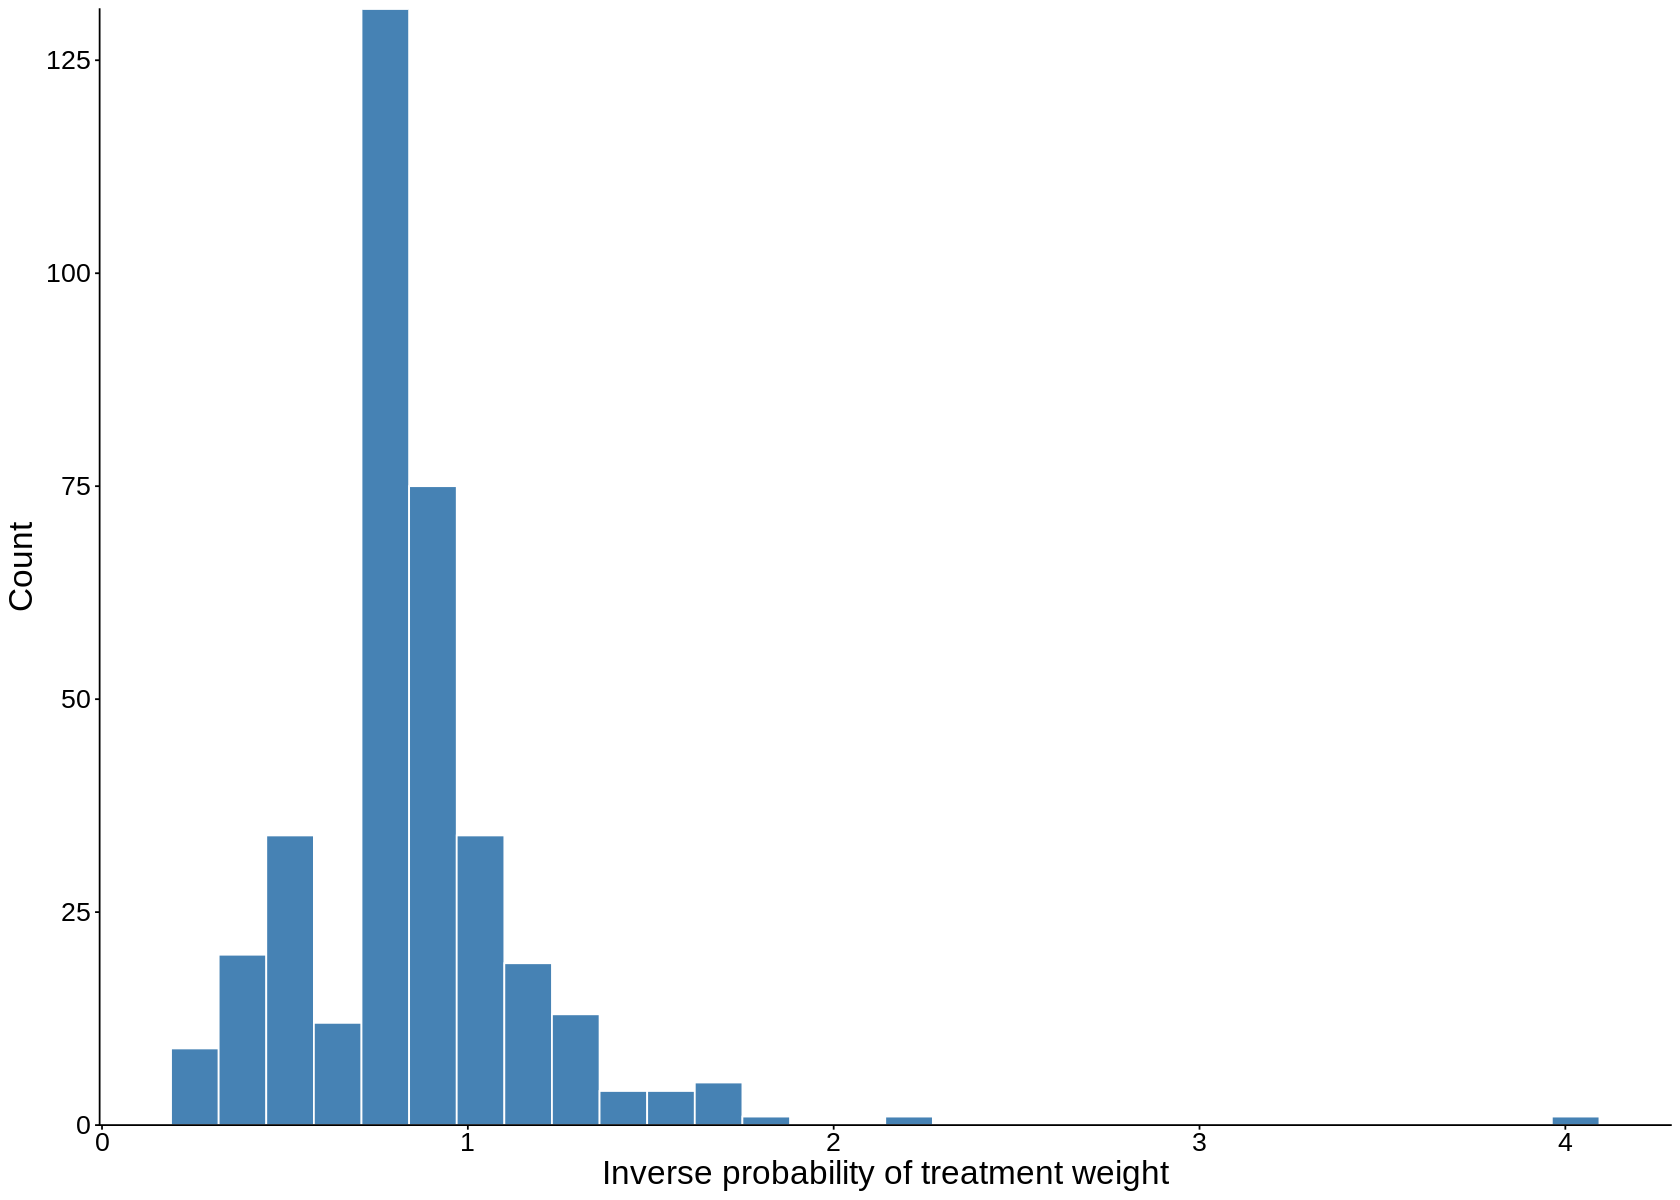

In [16]:
plot_s2<-ggplot(cc, aes(x = iptw)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  scale_y_continuous(expand = c(0,0))+
  theme_classic() +
  labs(x = "Inverse probability of treatment weight", y = "Count")+
  theme(text = element_text(size = 20))
plot_s2

In [17]:
svg("weight_histogram_s2.svg", width = 10, height = 7)
print(plot_s2)
dev.off()

agg_record_396113121 
                   2

Estimate OR

In [18]:
mod_cc <- glm(case ~ ap, weights = iptw, family = "quasibinomial", data = cc)
robust_results <- coeftest(mod_cc, vcov = vcovHC(mod_cc, type = "HC0"))
print(robust_results)


z test of coefficients:

            Estimate Std. Error  z value  Pr(>|z|)    
(Intercept) -2.00523    0.19416 -10.3279 < 2.2e-16 ***
apTRUE      -3.05668    1.02759  -2.9746  0.002934 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



OR (95% CI)

In [19]:
estimates <- robust_results[, 1]
sds <- robust_results[, 2]
OR_table <- exp(cbind(OR = estimates,
                      lower = estimates - 1.96 * sds,
                      upper = estimates + 1.96 * sds))
paste0("OR (95%CI): ",round(OR_table[2,1],2)," (",round(OR_table[2,2],2),", ",round(OR_table[2,3],2),")")

[1] "OR (95%CI): 0.05 (0.01, 0.35)"

VE (95%CI)

In [20]:
ve<-(1-OR_table)*100
paste0("VE (95%CI): ",round(ve[2,1],1)," (",round(ve[2,3],1),", ",round(ve[2,2],1),")")

[1] "VE (95%CI): 95.3 (64.7, 99.4)"

P value

In [21]:
round(robust_results[2, 4],3)

[1] 0.003

In [54]:
cc %>% group_by(case,ap) %>% summarise(n=n(), iptw = sum(iptw))

`summarise()` has grouped output by 'case'. You can override using the
`.groups` argument.


case,ap,n,iptw
<lgl>,<lgl>,<int>,<dbl>
FALSE,FALSE,245,229.4008059
FALSE,TRUE,85,49.2059950
TRUE,FALSE,32,30.8840301
TRUE,TRUE,1,0.3116442


# **Case VS Test-negative Control**

Subgroup data into TNCC

In [22]:
tnc<-ap[ap$group!="com-control",]
tnc$case<-tnc$group=="case"

IPTW

In [23]:
set.seed(123)
w.out <- weightit(
  formula  = ap ~ east + mage + gage + mode + income + smoke + wanc + panc + fluvac + sex + cage+ eperiod + bap + milk + hhchild + school + bw,
  data     = tnc,
  method   = "gbm",
  estimand = "ATE",
  stabilize= TRUE,
  stop.method = "smd.mean")

Assign IPTW

In [24]:
tnc$iptw<-w.out$weights

Show pre-weighting VS post-weighting result (NA=0)

In [25]:
bal_stats <- bal.tab(w.out, un = TRUE, stats = "m", abs = TRUE)$Balance %>%
  as.data.frame() %>%
  tibble::rownames_to_column("variable") %>%
  mutate(variable = gsub("_.*", "", variable)) %>%
  group_by(variable) %>%
  slice(1) %>%
  select(variable, SMD_Pre = Diff.Un, SMD_Post = Diff.Adj)
covs <- c("east", "mage", "gage", "mode", "income", "smoke",
                "wanc", "panc", "fluvac", "sex",
                "cage", "eperiod", "bap", "milk", "hhchild", "school")
tnc$one <- 1
pre_table  <- get_stats(tnc, "one") %>% rename(Pre_F = `FALSE`, Pre_T = `TRUE`)
post_table <- get_stats(tnc, "iptw") %>% rename(Post_F = `FALSE`, Post_T = `TRUE`)
final_table <- pre_table %>%
  left_join(post_table, by = c("variable", "level")) %>%
  left_join(bal_stats, by = "variable") %>%
  # Add the continuous 'bw' means/SDs as a separate step if desired
  arrange(variable, level)

In [26]:
final_table<-final_table %>% select(variable, level,  Pre_T, Pre_F, SMD_Pre, Post_T, Post_F,  SMD_Post)
names(final_table) <- c("variable", "level","Pre_aP", "Pre_No_aP", "SMD_Pre","Post_aP", "Post_No_aP",  "SMD_Post")
final_table

variable,level,Pre_aP,Pre_No_aP,SMD_Pre,Post_aP,Post_No_aP,SMD_Post
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
bap,DTaP,NA,1 (1.6%),0.01639344,NA,0.9 (1.5%),0.01501278
bap,DTwP,9 (69.2%),25 (41%),0.01639344,3.6 (62.2%),24.3 (42.2%),0.01501278
bap,None,4 (30.8%),35 (57.4%),0.01639344,2.2 (37.8%),32.4 (56.3%),0.01501278
cage,1,4 (30.8%),13 (21.3%),0.09457755,1.8 (30.9%),12.1 (20.9%),0.10017774
cage,2,1 (7.7%),14 (23%),0.09457755,0.6 (9.8%),13.2 (22.9%),0.10017774
cage,3,8 (61.5%),34 (55.7%),0.09457755,3.4 (59.3%),32.4 (56.1%),0.10017774
east,FALSE,9 (69.2%),30 (49.2%),0.20050441,4 (69.7%),28.5 (49.5%),0.20200384
east,TRUE,4 (30.8%),31 (50.8%),0.20050441,1.7 (30.3%),29.1 (50.5%),0.20200384
eperiod,Q1-2024,3 (23.1%),28 (45.9%),0.22824716,1.8 (30.6%),26.3 (45.5%),0.14893583


Total N for each arm (actual/pseudo-population)

In [27]:
tnc %>%
  group_by(ap) %>%
  summarise(
    n_pre = n(),
    n_post = sum(iptw, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  # Reshape to match the final_table structure
  summarise(
    variable = "Total N",
    Pre_aP = as.character(round(n_pre[ap == TRUE], 1)),
    Pre_No_aP = as.character(round(n_pre[ap == FALSE], 1)),
    Post_aP = as.character(round(n_post[ap == TRUE], 1)),
    Post_No_aP = as.character(round(n_post[ap == FALSE], 1)))

variable,Pre_aP,Pre_No_aP,Post_aP,Post_No_aP
<chr>,<chr>,<chr>,<chr>,<chr>
Total N,13,61,5.8,57.7


Check stability of IPTW

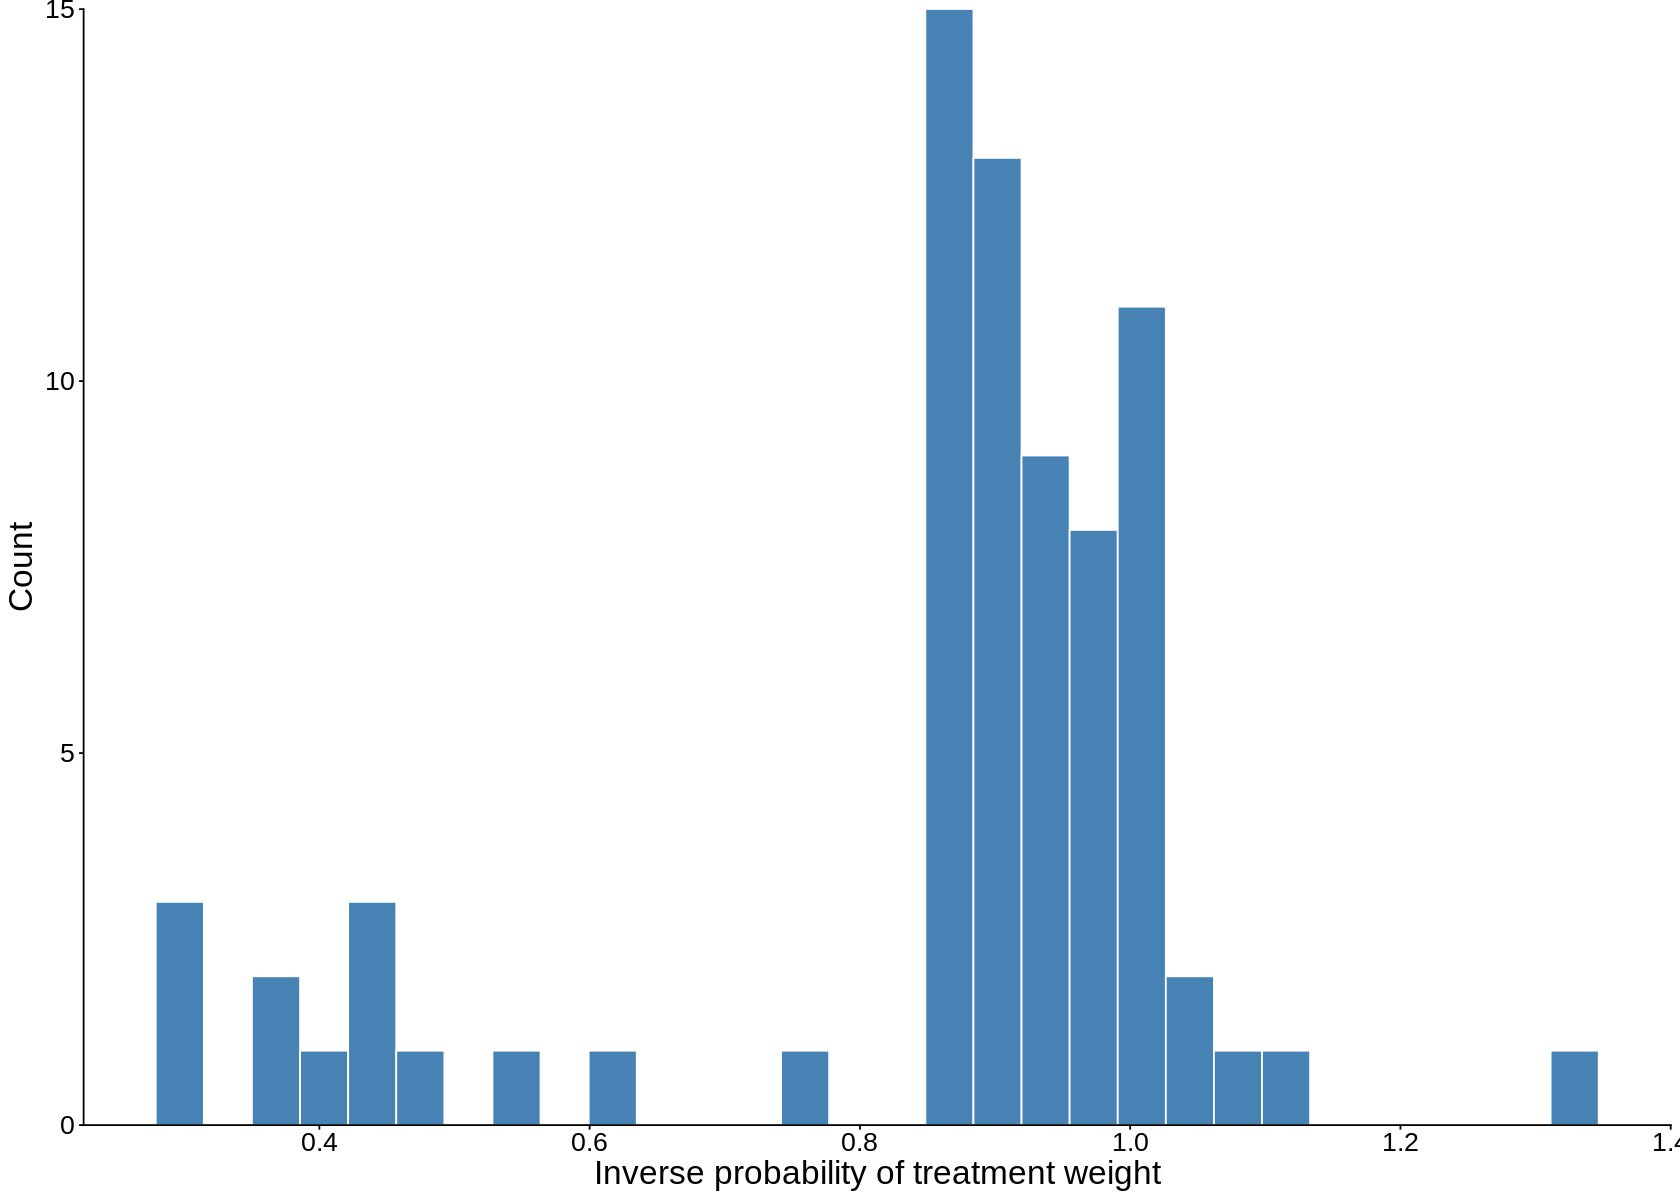

In [28]:
plot_s3<-ggplot(tnc, aes(x = iptw)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  scale_y_continuous(expand = c(0,0))+
  theme_classic() +
  labs(x = "Inverse probability of treatment weight", y = "Count")+
  theme(text = element_text(size = 20))
plot_s3

In [29]:
svg("weight_histogram_s3.svg", width = 10, height = 7)
print(plot_s3)
dev.off()

agg_record_2133132922 
                    2

Estimate OR

In [30]:
mod_tnc <- glm(case ~ ap, weights = iptw, family = "quasibinomial", data = tnc)
robust_results <- coeftest(mod_tnc, vcov = vcovHC(mod_tnc, type = "HC0"))
print(robust_results)


z test of coefficients:

            Estimate Std. Error z value Pr(>|z|)   
(Intercept)  0.10152    0.25733  0.3945 0.693197   
apTRUE      -2.99493    1.07515 -2.7856 0.005343 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



OR (95% CI)

In [31]:
estimates <- robust_results[, 1]
sds <- robust_results[, 2]
OR_table <- exp(cbind(OR = estimates,
                      lower = estimates - 1.96 * sds,
                      upper = estimates + 1.96 * sds))
paste0("OR (95%CI): ",round(OR_table[2,1],2)," (",round(OR_table[2,2],2),", ",round(OR_table[2,3],2),")")

[1] "OR (95%CI): 0.05 (0.01, 0.41)"

VE (95% CI)

In [32]:
ve<-(1-OR_table)*100
paste0("VE (95%CI): ",round(ve[2,1],1)," (",round(ve[2,3],1),", ",round(ve[2,2],1),")")

[1] "VE (95%CI): 95 (58.8, 99.4)"

P value

In [33]:
round(robust_results[2, 4],3)

[1] 0.005

In [55]:
tnc %>% group_by(case,ap) %>% summarise(n=n(), iptw = sum(iptw))

`summarise()` has grouped output by 'case'. You can override using the
`.groups` argument.


case,ap,n,iptw
<lgl>,<lgl>,<int>,<dbl>
FALSE,FALSE,29,27.3645158
FALSE,TRUE,12,5.4521904
TRUE,FALSE,32,30.2884928
TRUE,TRUE,1,0.3019822


# **Review medical records of the cases**

In [34]:
age<-ap[,c("id","ap","cage","bap")]

In [35]:
hos<-merge(hos,age,by = "id",all.x = T)

**Stratified clinical outcomes by age**

In [36]:
hos$status<-paste(hos$ap,hos$cage)

In [37]:
summary_results <- hos %>%
  group_by(status) %>%
  summarise(
    # Add Total N for each group
    TOTAL_N = n(),

    # Summarize logical variables
    across(cough:dead,
           list(n = ~sum(.x, na.rm = TRUE),
                prop = ~round(mean(.x, na.rm = TRUE), 2)),
           .names = "{.col}_{.fn}"),

    # Summarize numeric variables
    across(c(onset_dur, los),
           list(mean = ~round(mean(.x, na.rm = TRUE), 2),
                sd = ~round(sd(.x, na.rm = TRUE), 2)),
           .names = "{.col}_{.fn}")
  )

# 2. Transpose the table
summary_transposed <- summary_results %>%
  pivot_longer(cols = -status, names_to = "Variable", values_to = "Value") %>%
  pivot_wider(names_from = status, values_from = Value)

In [38]:
summary_transposed[1,]

Variable,FALSE 1,FALSE 2,FALSE 3,TRUE 3
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TOTAL_N,4,7,21,1


In [39]:
result <- summary_transposed %>%
  # 1. Reshape to long format to handle rows easily
  pivot_longer(cols = -Variable, names_to = "group", values_to = "value") %>%

  # 2. Extract the base name and the measure type (_n or _prop)
  # This regex splits 'cough_n' into 'cough' and 'n'
  extract(Variable, into = c("base_var", "type"), regex = "(.*)_(n|prop)$") %>%

  # 3. Handle rows that aren't n/prop (like TOTAL_N or mean/sd)
  filter(!is.na(type)) %>%

  # 4. Put n and prop next to each other
  pivot_wider(names_from = type, values_from = value) %>%

  # 5. Create the combined string
  mutate(combined = case_when(
    is.na(n) ~ NA_character_,
    TRUE ~ sprintf("%d (%.0f%%)", as.integer(n), prop * 100)
  )) %>%

  # 6. Cleanup and pivot back to your original wide layout
  select(base_var, group, combined) %>%
  pivot_wider(names_from = group, values_from = combined) %>%
  rename(Variable = base_var)

In [40]:
names(result)<-c("outcome","1_Month_without_aP","2_Month_without_aP","3_Month_without_aP","3_Month_with_aP")

In [41]:
result

outcome,1_Month_without_aP,2_Month_without_aP,3_Month_without_aP,3_Month_with_aP
<chr>,<chr>,<chr>,<chr>,<chr>
cough,3 (75%),2 (29%),16 (76%),1 (100%)
cyanosis,0 (0%),2 (29%),2 (10%),0 (0%)
whooping,3 (75%),2 (29%),7 (33%),0 (0%)
apnea,2 (50%),0 (0%),0 (0%),0 (0%)
seizure,1 (25%),0 (0%),0 (0%),0 (0%)
admit,4 (100%),6 (86%),16 (76%),1 (100%)
ett,3 (75%),1 (14%),3 (14%),0 (0%)
pnuemo,3 (75%),2 (29%),7 (33%),0 (0%)
dead,2 (50%),0 (0%),1 (5%),0 (0%)


**Stratified clinical outcomes by DTwP/DTaP vaccination before the onset of symptom**

In [42]:
hos$status<-paste(hos$ap,hos$bap)

In [43]:
summary_results <- hos %>%
  group_by(status) %>%
  summarise(
    # Add Total N for each group
    TOTAL_N = n(),

    # Summarize logical variables
    across(cough:dead,
           list(n = ~sum(.x, na.rm = TRUE),
                prop = ~round(mean(.x, na.rm = TRUE), 2)),
           .names = "{.col}_{.fn}"),

    # Summarize numeric variables
    across(c(onset_dur, los),
           list(mean = ~round(mean(.x, na.rm = TRUE), 2),
                sd = ~round(sd(.x, na.rm = TRUE), 2)),
           .names = "{.col}_{.fn}")
  )

# 2. Transpose the table
summary_transposed <- summary_results %>%
  pivot_longer(cols = -status, names_to = "Variable", values_to = "Value") %>%
  pivot_wider(names_from = status, values_from = Value)

In [44]:
summary_transposed[1,]

Variable,FALSE DTaP,FALSE DTwP,FALSE None,TRUE DTwP
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TOTAL_N,1,11,20,1


In [45]:
result2 <- summary_transposed %>%
  # 1. Reshape to long format to handle rows easily
  pivot_longer(cols = -Variable, names_to = "group", values_to = "value") %>%

  # 2. Extract the base name and the measure type (_n or _prop)
  # This regex splits 'cough_n' into 'cough' and 'n'
  extract(Variable, into = c("base_var", "type"), regex = "(.*)_(n|prop)$") %>%

  # 3. Handle rows that aren't n/prop (like TOTAL_N or mean/sd)
  filter(!is.na(type)) %>%

  # 4. Put n and prop next to each other
  pivot_wider(names_from = type, values_from = value) %>%

  # 5. Create the combined string
  mutate(combined = case_when(
    is.na(n) ~ NA_character_,
    TRUE ~ sprintf("%d (%.0f%%)", as.integer(n), prop * 100)
  )) %>%

  # 6. Cleanup and pivot back to your original wide layout
  select(base_var, group, combined) %>%
  pivot_wider(names_from = group, values_from = combined) %>%
  rename(Variable = base_var)

In [46]:
result2

Variable,FALSE DTaP,FALSE DTwP,FALSE None,TRUE DTwP
<chr>,<chr>,<chr>,<chr>,<chr>
cough,1 (100%),7 (64%),13 (65%),1 (100%)
cyanosis,0 (0%),4 (36%),0 (0%),0 (0%)
whooping,0 (0%),3 (27%),9 (45%),0 (0%)
apnea,0 (0%),0 (0%),2 (10%),0 (0%)
seizure,0 (0%),0 (0%),1 (5%),0 (0%)
admit,1 (100%),9 (82%),16 (80%),1 (100%)
ett,0 (0%),2 (18%),5 (25%),0 (0%)
pnuemo,0 (0%),3 (27%),9 (45%),0 (0%)
dead,0 (0%),0 (0%),3 (15%),0 (0%)


Consider combine DTwP and DTaP of child vaccination

In [47]:
hos$status<-paste(hos$ap,hos$bap!="None")

In [48]:
summary_results <- hos %>%
  group_by(status) %>%
  summarise(
    # Add Total N for each group
    TOTAL_N = n(),

    # Summarize logical variables
    across(cough:dead,
           list(n = ~sum(.x, na.rm = TRUE),
                prop = ~round(mean(.x, na.rm = TRUE), 2)),
           .names = "{.col}_{.fn}"),

    # Summarize numeric variables
    across(c(onset_dur, los),
           list(mean = ~round(mean(.x, na.rm = TRUE), 2),
                sd = ~round(sd(.x, na.rm = TRUE), 2)),
           .names = "{.col}_{.fn}")
  )

# 2. Transpose the table
summary_transposed <- summary_results %>%
  pivot_longer(cols = -status, names_to = "Variable", values_to = "Value") %>%
  pivot_wider(names_from = status, values_from = Value)

In [49]:
summary_transposed[1,]

Variable,FALSE FALSE,FALSE TRUE,TRUE TRUE
<chr>,<dbl>,<dbl>,<dbl>
TOTAL_N,20,12,1


In [50]:
result3 <- summary_transposed %>%
  # 1. Reshape to long format to handle rows easily
  pivot_longer(cols = -Variable, names_to = "group", values_to = "value") %>%

  # 2. Extract the base name and the measure type (_n or _prop)
  # This regex splits 'cough_n' into 'cough' and 'n'
  extract(Variable, into = c("base_var", "type"), regex = "(.*)_(n|prop)$") %>%

  # 3. Handle rows that aren't n/prop (like TOTAL_N or mean/sd)
  filter(!is.na(type)) %>%

  # 4. Put n and prop next to each other
  pivot_wider(names_from = type, values_from = value) %>%

  # 5. Create the combined string
  mutate(combined = case_when(
    is.na(n) ~ NA_character_,
    TRUE ~ sprintf("%d (%.0f%%)", as.integer(n), prop * 100)
  )) %>%

  # 6. Cleanup and pivot back to your original wide layout
  select(base_var, group, combined) %>%
  pivot_wider(names_from = group, values_from = combined) %>%
  rename(Variable = base_var)

In [51]:
names(result3)<-c("outcome","NoMaP_NoCaP","NoMaP_CaP","MaP_CaP")

In [52]:
result3

outcome,NoMaP_NoCaP,NoMaP_CaP,MaP_CaP
<chr>,<chr>,<chr>,<chr>
cough,13 (65%),8 (67%),1 (100%)
cyanosis,0 (0%),4 (33%),0 (0%)
whooping,9 (45%),3 (25%),0 (0%)
apnea,2 (10%),0 (0%),0 (0%)
seizure,1 (5%),0 (0%),0 (0%)
admit,16 (80%),10 (83%),1 (100%)
ett,5 (25%),2 (17%),0 (0%)
pnuemo,9 (45%),3 (25%),0 (0%)
dead,3 (15%),0 (0%),0 (0%)
